In [ ]:
import matplotlib.pyplot as plt
from pydas.simulation_manager import BuildingEnergySimulator, RCBuilding3R2C, SupplyController # Importing necessary simulator tools.
from pydas.constants import CP_WATER

parameters_3R2C = { # There are four parameters (two resistances and two capacitances).
    "thermal_capacitance_air": 5.0, # In units of kWh / K.,
    "thermal_conductance_air": 0.5, # In units of Kw / K.
    "thermal_capacitance_wall": 50.0, # In units of kWh / K.,
    "thermal_conductance_wall": 0.3, # In units of Kw / K.
    "mass_flow": 500.0  # kg / h . NOTE: Mass flow is going to have to be variable and supply termperature more static probably.
}

In [ ]:
bes = BuildingEnergySimulator(timestep = 1.0) # Time step is one hour [Units of hour is used by default].
bes.load_outdoor_temperature_data("../data/smhi_gotenburg.csv") # For now, loading a weather file that has at least hourly resolution which is a station in Gothenburg.
controller = SupplyController(maximum_heating_power = 10.0) # An external "controller" that supplies heating power instantaneously.
controller.supply_temperature_upper = 80.0
controller.supply_temperature_lower = 60.0
rcbuilding = RCBuilding3R2C(parameters = parameters_3R2C) # A RC model instance for the considered building.
bes.add_rcbuilding(rcbuilding) # Lets the simulator orchestrator have access to building members and methods.
bes.add_controller(controller) # Lets the simulator orchestrator have access to controller members and methods.

In [21]:
## Allocate some lists for storing temperature states.
recorded_indoor_temperatures = []
recorded_wall_temperatures = []
recorded_setpoints = []
recorded_heat_extract = []
number_of_iterations = len(bes.outdoor_temperature_data.index)
print(f"Simulation will contain {number_of_iterations} one-hour timesteps.")

Simulation will contain 3139 one-hour timesteps.


In [22]:
%%time
for it in range(number_of_iterations):
    recorded_heat_extract.append(bes.get_extracted_heat())
    recorded_setpoints.append(rcbuilding.setpoint_temperature_callback(bes.outdoor_temperature_data["timestamp"].dt.hour[it])) # Get the current setpoint temperature, based on a very simple rule.
    recorded_indoor_temperatures.append(rcbuilding.state["indoor_temperature"]) # Get the corresponding instantaneous indoor temperature.
    recorded_wall_temperatures.append(rcbuilding.state["wall_temperature"]) # Get the corresponding instantaneous wall temperature.
    bes.step_ST() # Update the simulation one hour forward (one timestep).

CPU times: total: 1.66 s
Wall time: 1.75 s


(0.0, 1000.0)

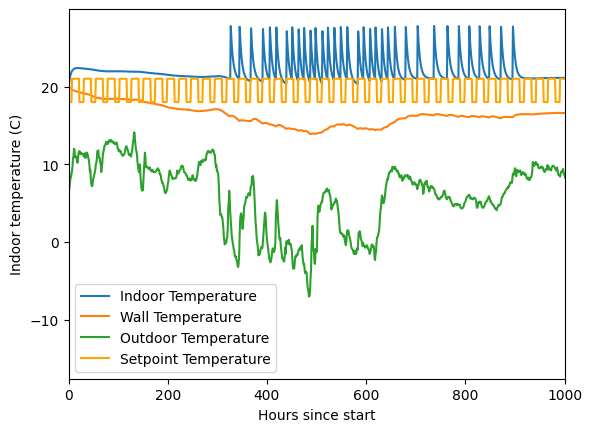

In [25]:
plt.plot(recorded_indoor_temperatures, label = "Indoor Temperature")
plt.plot(recorded_wall_temperatures, label = "Wall Temperature")
plt.plot(bes.outdoor_temperature_data["Lufttemperatur"], label = "Outdoor Temperature")
plt.plot(recorded_setpoints, color = "orange", label = "Setpoint Temperature")
plt.xlabel("Hours since start")
plt.ylabel("Indoor temperature (C)")
plt.legend()

plt.xlim(0, 1000)

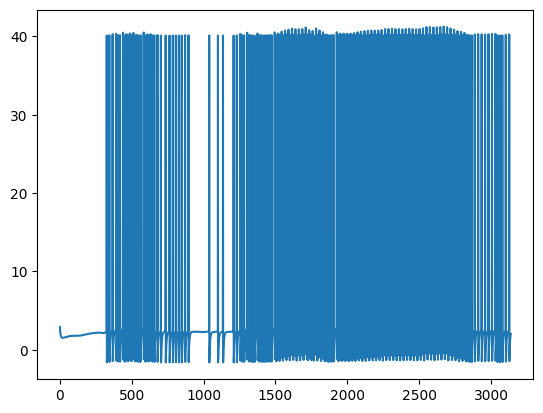

In [24]:
plt.plot(recorded_heat_extract)